# Institutional Holdings Graph: Point-in-Time 13F Features

**Docker image**: `ml4t`

**Chapter 22: RAG for Financial Research** (Section 22.8)

This notebook constructs a bipartite institution-stock graph from 13F
holdings and derives co-ownership similarity, crowding, and institutional
ownership-change descriptors for downstream research.

**Learning Objectives**:
- Build a normalized institution-by-stock ownership matrix and translate it
  into stock-stock cosine similarity
- Engineer cross-sectional ownership-breadth and ownership-change features
- Identify portfolio overlap and strategy clusters via institution-institution
  similarity
- Inspect the stock-level features that downstream GNN pipelines consume
  (the canonical downloader is the producer; Chapter 23 is the consumer)

**Book Reference**: Chapter 22, Section 22.8 (Applications)

**Prerequisites**: The raw 13F holdings are produced by the canonical
downloader at `data/equities/positioning/13f_download.py`; run it once
before this notebook (or see `data/equities/fundamentals/README.md`).
The download mechanics (SEC EDGAR submissions API, XML information tables)
are covered in Chapter 4, NB 05.

## What 13F Data Exposes

- **Delayed disclosure**: reporting-quarter positions become observable only
  on their SEC filing dates
- **Manager-level positions**: Quarter-end long equity holdings by reporting
  institution, joinable to price data for downstream feature studies
- **Crowding descriptors**: Breadth and concentration summarize how disclosed
  ownership is distributed; liquidation pressure is not measured here
- **Co-ownership structure**: Stocks sharing institutional holders form a
  bipartite graph usable for similarity and clustering analysis

## Setup

These parameters set the institution universe and the filing horizon. The raw
data is already on disk; this notebook loads it through the canonical loader
and narrows it.

In [1]:
"""Institutional Holdings Graph - point-in-time 13F ownership descriptors."""

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import display
from polars.testing import assert_frame_equal

from data import load_13f_edges, load_13f_stock_features, load_institutional_holdings_13f
from utils.style import COLORS, show_plotly_with_alt

The institution universe is a list of CIKs and the display name comes from
the filing, not from this file. The CIK is the identity, and a hand-written
label that disagrees with the filer renames a manager in every table
downstream. This notebook carried one: 0001450144 was written as "Two Sigma
Investments", and that CIK files as TWO SIGMA SECURITIES, LLC - the
market-making entity, a different book from Two Sigma Investments LP.

Extend the list to widen the analysis; rows for any other CIK in the artifact
are dropped.

In [2]:
NUM_QUARTERS = 4
MAX_INSTITUTIONS = 0

SELECTED_CIKS = [
    "0001067983",
    "0001350694",
    "0001037389",
    "0001450144",
    "0001009207",
    "0001167557",
    "0001423053",
    "0001273087",
    "0001603466",
    "0001167483",
]

In [3]:
if MAX_INSTITUTIONS > 0:
    SELECTED_CIKS = SELECTED_CIKS[:MAX_INSTITUTIONS]

print(f"Institution filter: {len(SELECTED_CIKS)}")
print(f"Quarters to retain: {NUM_QUARTERS}")

Institution filter: 10
Quarters to retain: 4


## Part 1: Load Holdings Data

`data/equities/positioning/13f_download.py` fetches 13F-HR filings from SEC
EDGAR, parses each information table, and writes a single
`institutional_holdings.parquet` artifact to
`$ML4T_DATA_PATH/equities/positioning/13f/`. We read that artifact
directly and narrow it to the institutions and quarters of interest.

If the file is missing, the loader raises `DataNotFoundError` with a pointer
to the downloader and its README.

The institution count and the quarter window set the graph's density, and
every descriptor below inherits them. Ten managers is a small universe, and
Part 3 shows what that does to a similarity computed over it.

In [4]:
holdings_df = load_institutional_holdings_13f()
required_provenance = {"report_date", "put_call"}
missing_provenance = required_provenance - set(holdings_df.columns)
if missing_provenance:
    raise ValueError(
        "The canonical 13F artifact lacks required SEC provenance: "
        f"{sorted(missing_provenance)}. Regenerate it with the canonical downloader."
    )
if holdings_df.schema["report_date"] != pl.Date:
    raise TypeError("Canonical 13F report_date must use the Polars Date type.")

Whether a manager filed for a quarter, and when that quarter became public,
are questions about what was *disclosed* rather than about what enters the
graph. The producer counts any disclosed row as evidence a manager filed, so
both are answered from the selected holdings before the option filter below:
a manager disclosing options only has still filed. Reading coverage off the
filtered frame would make this notebook reject a quarter the producer used,
and the parity assertion at the end would compare two different quarters.

In [5]:
holdings_df = holdings_df.filter(pl.col("cik").is_in(SELECTED_CIKS))
disclosed_df = holdings_df
option_rows = holdings_df.filter(
    pl.col("put_call").fill_null("").cast(pl.Utf8).str.strip_chars() != ""
).height
holdings_df = holdings_df.filter(
    pl.col("put_call").fill_null("").cast(pl.Utf8).str.strip_chars() == ""
)
print(f"Excluded {option_rows:,} put/call rows; retained long-equity rows only.")

if holdings_df["filing_date"].min().isoformat() < "2023-01-03":
    raise ValueError("Pre-2023 13F values require a thousands-to-dollars conversion.")

# The producer retains its legacy `value_thousands` field name, but SEC filings
# after 2023-01-03 report market value in dollars. SEC reportDate supplies the
# authoritative quarter identity; filing date remains the availability time.
holdings_df = holdings_df.with_columns(
    pl.col("value_thousands").cast(pl.Float64).alias("reported_value_usd"),
    pl.col("report_date").alias("report_period"),
)

Excluded 47,181 put/call rows; retained long-equity rows only.


A reporting quarter becomes available only once the last included manager has
filed for it. Duplicate CIK/CUSIP rows inside one information table are
summed rather than picked from positionally.

In [6]:
quarter_availability = (
    disclosed_df.with_columns(pl.col("report_date").alias("report_period"))
    .group_by("report_period")
    .agg(pl.col("filing_date").max().alias("timestamp"))
)

Canonicalize each CUSIP's issuer label by the largest disclosed value in that
reporting period, with a lexical tie-break, so a manager's spacing or
abbreviation does not decide how a company is named below.

A quarter then enters the graph only once every covered manager has filed for
it. Filings are due 45 days after quarter end, so inside that window the
newest quarter holds the early filers only, and their peers' absence would
read as a mass exit rather than as missing coverage. The downloader applies
the same rule, which is what keeps the reconstruction at the end of this
notebook equal to its artifacts.

In [7]:
issuer_names = (
    holdings_df.group_by(["cusip", "report_period", "issuer"])
    .agg(pl.col("reported_value_usd").sum().alias("issuer_value_usd"))
    .sort(
        ["cusip", "report_period", "issuer_value_usd", "issuer"],
        descending=[False, False, True, False],
    )
    .unique(subset=["cusip", "report_period"], keep="first", maintain_order=True)
    .select("cusip", "report_period", pl.col("issuer").alias("issuer"))
)
positions_df = (
    holdings_df.group_by(["cik", "cusip", "report_period"])
    .agg(
        pl.col("company_name").sort().first().alias("company_name"),
        pl.col("reported_value_usd").sum().alias("reported_value_usd"),
        pl.col("shares").sum().alias("shares"),
    )
    .filter(pl.col("reported_value_usd") > 0)
    .join(issuer_names, on=["cusip", "report_period"], how="left")
    .join(quarter_availability, on="report_period", how="left")
)

covered_ciks = disclosed_df["cik"].n_unique()
complete_periods = (
    disclosed_df.with_columns(pl.col("report_date").alias("report_period"))
    .group_by("report_period")
    .agg(pl.col("cik").n_unique().alias("n_ciks"))
    .filter(pl.col("n_ciks") == covered_ciks)["report_period"]
    .to_list()
)
if not complete_periods:
    raise ValueError(
        f"No reporting quarter is covered by all {covered_ciks} institutions in the "
        "artifact, so no graph can be built without treating missing filers as exits."
    )
partial_periods = sorted(
    set(positions_df["report_period"].unique().to_list()) - set(complete_periods)
)
if partial_periods:
    print(
        f"Excluded {len(partial_periods)} partially filed quarter(s): "
        f"{', '.join(str(p) for p in partial_periods)}"
    )
positions_df = positions_df.filter(pl.col("report_period").is_in(complete_periods))
# Held before NUM_QUARTERS narrows the display: the change table is computed
# over the artifact's last two complete quarters, as the producer does.
complete_positions_df = positions_df

if NUM_QUARTERS > 0:
    recent_periods = (
        positions_df["report_period"].unique().sort(descending=True).head(NUM_QUARTERS).to_list()
    )
    positions_df = positions_df.filter(pl.col("report_period").is_in(recent_periods))

assert (
    positions_df.select(pl.struct(["cik", "cusip", "report_period"]).is_duplicated().any()).item()
    is False
)

print(
    f"\nTotal: {len(positions_df):,} aggregated positions across "
    f"{positions_df['report_period'].n_unique()} reporting quarters and "
    f"{positions_df['cik'].n_unique()} institutions"
)


Total: 95,845 aggregated positions across 4 reporting quarters and 10 institutions


Each row is a position disclosed as of a quarter end, not evidence about
what was held between quarter ends. A manager can open and close a position
inside a quarter and disclose neither.

## Part 2: Bipartite Graph Construction

The fundamental structure is an **Institution -> Stock** edge list with value
and share weights that can be reused for graph analytics and feature export.

In [8]:
# Get most recent snapshot per institution-stock pair
if len(positions_df) > 0:
    latest_period = positions_df["report_period"].max()
    latest_holdings = positions_df.filter(pl.col("report_period") == latest_period)

    n_inst = latest_holdings["cik"].n_unique()
    n_stocks = latest_holdings["cusip"].n_unique()
    n_edges = len(latest_holdings)

    print("=== Bipartite Graph Structure ===")
    print(f"Institution nodes: {n_inst}")
    print(f"Stock nodes: {n_stocks}")
    print(f"Edges (holdings): {n_edges:,}")
    print(f"Density: {n_edges / (n_inst * n_stocks):.4f}")
    print(f"Avg holdings per institution: {n_edges / n_inst:.0f}")
    print(f"Avg institutions per stock: {n_edges / n_stocks:.2f}")
else:
    latest_holdings = positions_df

=== Bipartite Graph Structure ===
Institution nodes: 10
Stock nodes: 7998
Edges (holdings): 24,672
Density: 0.3085
Avg holdings per institution: 2467
Avg institutions per stock: 3.08


## Part 3: Co-Ownership Analysis

**Key insight**: Common disclosed owners create a stock-stock similarity graph useful for:
- Portfolio diversification (avoid co-owned stocks)
- Factor construction (co-ownership as a factor)
- Risk management (crowding detection)

Read the density above before the similarities below. It is the share of
possible institution-stock edges that exist, and at ten managers each holding
thousands of names it is not small.

In [9]:
def build_ownership_matrix(holdings: pl.DataFrame) -> tuple[np.ndarray, list[str]]:
    """Build an institution-by-stock matrix weighted by reported position value."""
    stocks = sorted(holdings["cusip"].unique().to_list())
    institutions = sorted(holdings["cik"].unique().to_list())
    stock_idx = {s: i for i, s in enumerate(stocks)}
    inst_idx = {c: i for i, c in enumerate(institutions)}

    ownership = np.zeros((len(institutions), len(stocks)), dtype=np.float32)
    for row in holdings.iter_rows(named=True):
        ownership[inst_idx[row["cik"]], stock_idx[row["cusip"]]] = row["reported_value_usd"]

    row_sums = ownership.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return ownership / row_sums, stocks

### Stock co-ownership similarity

Convert the normalized institution-by-stock matrix into a stock-by-stock
cosine-similarity matrix for crowding and overlap analysis.


In [10]:
def compute_coownership_matrix(holdings: pl.DataFrame) -> tuple[np.ndarray, list[str]]:
    """Compute the stock-level co-ownership similarity matrix."""
    ownership_norm, stocks = build_ownership_matrix(holdings)
    coown = ownership_norm.T @ ownership_norm
    diag = np.sqrt(np.diag(coown))
    diag[diag == 0] = 1
    similarity = coown / np.outer(diag, diag)
    return similarity, stocks

In [11]:
if len(latest_holdings) > 0:
    coown_matrix, stock_list = compute_coownership_matrix(latest_holdings)
    np.fill_diagonal(coown_matrix, 0)
    row_idx, col_idx = np.triu_indices_from(coown_matrix, k=1)
    pair_values = coown_matrix[row_idx, col_idx]

    ownership_norm, _ = build_ownership_matrix(latest_holdings)
    holder_counts = (ownership_norm > 0).sum(axis=0)

    print("=== Co-Ownership Matrix ===")
    print(f"Shape: {coown_matrix.shape} over {len(pair_values):,} distinct stock pairs")
    print(f"Pairs sharing no holder at all: {(pair_values == 0).mean():.1%}")
    print(f"Pairs below 1% similarity:      {(pair_values < 0.01).mean():.1%}")
    print(f"Pairs at or above 0.999:        {(pair_values >= 0.999).mean():.1%}")

=== Co-Ownership Matrix ===
Shape: (7998, 7998) over 31,980,003 distinct stock pairs
Pairs sharing no holder at all: 22.5%
Pairs below 1% similarity:      27.8%
Pairs at or above 0.999:        5.3%


### Why so many pairs sit at the maximum

The similarity is a cosine between two columns of a matrix with one row per
institution, and there are ten institutions. A stock held by exactly one of
them is a vector pointing along one axis, so any two stocks held by the same
single institution have a cosine of exactly 1 - not because they are alike in
any way an investor would recognise, but because there is one dimension of
evidence about each of them and it happens to be the same one.

The count below is what that does to the top of the ranking.

In [12]:
if len(latest_holdings) > 0:
    saturated = pair_values >= 0.999
    single_holder_share = float((holder_counts == 1).mean())
    if saturated.any():
        endpoints = np.concatenate(
            [holder_counts[row_idx[saturated]], holder_counts[col_idx[saturated]]]
        )
        one_holder_endpoints = float((endpoints == 1).mean())
        print(
            f"Stocks held by exactly one institution: {(holder_counts == 1).sum():,} of "
            f"{len(holder_counts):,} ({single_holder_share:.0%})"
        )
        print(f"Pairs at similarity >= 0.999: {int(saturated.sum()):,}")
        print(f"  of their endpoints, {one_holder_endpoints:.0%} are single-holder stocks")
        print(f"  median holders per endpoint: {int(np.median(endpoints))}")

Stocks held by exactly one institution: 2,887 of 7,998 (36%)
Pairs at similarity >= 0.999: 1,703,410
  of their endpoints, 94% are single-holder stocks
  median holders per endpoint: 1


So "the highest co-ownership pair" is not a fact about two securities. It is
one arbitrary member of a very large tie, and the notebook used to print it
to three decimal places as though it had found something.

The obvious repair is to require a minimum number of holders. The sweep below
measures how much that buys, and it also shows what it does not fix.

In [13]:
if len(latest_holdings) > 0:
    floor_rows = []
    for floor in (1, 2, 3, 5, 8):
        eligible = np.flatnonzero(holder_counts >= floor)
        if len(eligible) < 2:
            continue
        block = coown_matrix[np.ix_(eligible, eligible)]
        upper = block[np.triu_indices_from(block, k=1)]
        columns = ownership_norm[:, eligible]
        top_share = columns.max(axis=0) / columns.sum(axis=0)
        floor_rows.append(
            {
                "min_holders": floor,
                "stocks": len(eligible),
                "pairs_at_or_above_0999_pct": round(100 * float((upper >= 0.999).mean()), 4),
                "max_similarity": round(float(upper.max()), 4),
                "median_top_holder_share": round(float(np.median(top_share)), 2),
            }
        )
    display(pl.DataFrame(floor_rows))

min_holders,stocks,pairs_at_or_above_0999_pct,max_similarity,median_top_holder_share
i64,i64,f64,f64,f64
1,7998,5.3265,1.0,0.83
2,5111,0.3324,1.0,0.6
3,3891,0.0718,1.0,0.54
5,2339,0.0054,1.0,0.46
8,139,0.0,0.998,0.37


Requiring more holders thins the saturation sharply - the share of pairs at
the top of the scale falls by orders of magnitude across those rows - and it
does not reach zero until the floor is high enough to leave very few stocks.
The last column says why.

A cosine is dominated by the largest component, not by the count of non-zero
ones. A stock held by five managers where one of them holds most of the
position is, for this purpose, almost a one-dimensional vector, and two such
stocks sharing that dominant manager score close to 1 whatever the other four
do. The median top-holder share falls as the floor rises, which is the real
mechanism behind the sweep: raising the holder floor works because it
incidentally selects less concentrated names.

The pair below is the highest-scoring one at a floor of half the managers,
printed with each stock's largest single weight so the reader can see this
happening rather than take it on trust.

In [14]:
if len(latest_holdings) > 0:
    min_holders = max(2, latest_holdings["cik"].n_unique() // 2)
    eligible = holder_counts >= min_holders
    pair_ok = eligible[row_idx] & eligible[col_idx]
    if pair_ok.any():
        candidates = np.flatnonzero(pair_ok)
        best = candidates[np.argmax(pair_values[candidates])]
        stock_a, stock_b = stock_list[row_idx[best]], stock_list[col_idx[best]]
        name_a = latest_holdings.filter(pl.col("cusip") == stock_a)["issuer"].first()
        name_b = latest_holdings.filter(pl.col("cusip") == stock_b)["issuer"].first()
        column_a = ownership_norm[:, row_idx[best]]
        column_b = ownership_norm[:, col_idx[best]]
        print(f"Highest co-ownership among stocks held by at least {min_holders} managers:")
        print(
            f"  {name_a} ({stock_a}), {holder_counts[row_idx[best]]} holders, "
            f"largest weight {column_a.max() / column_a.sum():.0%}"
        )
        print(
            f"  {name_b} ({stock_b}), {holder_counts[col_idx[best]]} holders, "
            f"largest weight {column_b.max() / column_b.sum():.0%}"
        )
        print(f"  Similarity: {pair_values[best]:.5f}")
    else:
        print(f"No pair of stocks is held by {min_holders} or more managers.")

Highest co-ownership among stocks held by at least 5 managers:
  DR REDDYS LABS LTD (256135203), 5 holders, largest weight 95%
  NATIONAL BEVERAGE CORP (635017106), 5 holders, largest weight 94%
  Similarity: 0.99997


The similarity still measures agreement in disclosed portfolio weights and
still says nothing about return comovement.

The check worth carrying out of this section is not the holder floor. It is
to report a concentration alongside any similarity computed over a short
vector, because the two together say whether the number rests on one
observation or on several, and the similarity alone cannot.

## Part 4: Institutional Ownership Change

**Construction**: Aggregate change in institutional ownership across quarters.
This notebook measures the construction; whether the resulting feature carries
forward-return predictive content is an empirical question that downstream
Chapter 11/12 pipelines evaluate against price data, not a claim made here.

### Select comparable quarter snapshots

Rename period-specific fields before joining the latest two reporting periods.

In [15]:
def select_stock_quarter(df: pl.DataFrame, period, suffix: str) -> pl.DataFrame:
    return df.filter(pl.col("report_period") == period).select(
        "cusip",
        pl.col("issuer_name").alias(f"issuer_{suffix}"),
        pl.col("quarter_value_usd").alias(f"value_{suffix}_usd"),
        pl.col("n_institutions").alias(f"n_institutions_{suffix}"),
    )

In [16]:
if len(complete_positions_df) > 0 and complete_positions_df["report_period"].n_unique() > 1:
    stock_quarter = complete_positions_df.group_by(["cusip", "report_period"]).agg(
        pl.col("issuer").first().alias("issuer_name"),
        pl.col("reported_value_usd").sum().alias("quarter_value_usd"),
        pl.col("cik").n_unique().alias("n_institutions"),
        pl.col("timestamp").max().alias("timestamp"),
    )
    comparison_periods = stock_quarter["report_period"].unique().sort(descending=True).head(2)
    current_period, prior_period = comparison_periods.to_list()
    current_availability = complete_positions_df.filter(pl.col("report_period") == current_period)[
        "timestamp"
    ].max()
    prior = select_stock_quarter(stock_quarter, prior_period, "q1")
    current = select_stock_quarter(stock_quarter, current_period, "q2")
    qoq = (
        prior.join(current, on="cusip", how="full", coalesce=True)
        .with_columns(
            pl.coalesce("issuer_q2", "issuer_q1").alias("issuer_name"),
            pl.lit(current_availability).alias("timestamp"),
            pl.col("value_q1_usd").fill_null(0),
            pl.col("value_q2_usd").fill_null(0),
            pl.col("n_institutions_q1").fill_null(0),
            pl.col("n_institutions_q2").fill_null(0),
        )
        .with_columns(
            (pl.col("value_q2_usd") - pl.col("value_q1_usd")).alias("value_change_usd"),
            pl.max_horizontal("n_institutions_q1", "n_institutions_q2").alias("n_institutions"),
            pl.when(pl.col("value_q1_usd") > 0)
            .then((pl.col("value_q2_usd") - pl.col("value_q1_usd")) / pl.col("value_q1_usd"))
            .otherwise(None)
            .alias("pct_change"),
        )
    )
else:
    qoq = None
    print("Need multiple quarters for ownership-change analysis")

### Inspect ownership-change leaders and exits

Use the quarter-over-quarter change table to identify broad institutional
buying, selling, new entries, and full exits.

The comparison runs between the two most recent quarters that every included
manager filed for, so a manager missing from the newest quarter cannot read
as a mass exit.

In [17]:
if qoq is not None:
    print("=== Institutional Ownership Changes ===")

    top_buys = (
        qoq.filter(pl.col("value_change_usd") > 0)
        .sort("value_change_usd", descending=True)
        .head(10)
    )
    print("\nTop 10 Institutional Buys (by $ change):")
    print(
        top_buys.select(
            [
                "issuer_name",
                pl.col("cusip").str.slice(-4).alias("cusip_tail"),
                "n_institutions",
                "value_q1_usd",
                "value_q2_usd",
                "value_change_usd",
            ]
        ).head(10)
    )

    top_sells = qoq.filter(pl.col("value_change_usd") < 0).sort("value_change_usd").head(10)
    print("\nTop 10 Institutional Sells (by $ change):")
    print(
        top_sells.select(
            [
                "issuer_name",
                pl.col("cusip").str.slice(-4).alias("cusip_tail"),
                "n_institutions",
                "value_q1_usd",
                "value_q2_usd",
                "value_change_usd",
            ]
        ).head(10)
    )

    new_positions = qoq.filter(pl.col("value_q1_usd") == 0).filter(pl.col("value_q2_usd") > 0)
    exits = qoq.filter(pl.col("value_q2_usd") == 0).filter(pl.col("value_q1_usd") > 0)
    print(f"\nNew positions initiated: {len(new_positions)}")
    print(f"Complete exits: {len(exits)}")

=== Institutional Ownership Changes ===

Top 10 Institutional Buys (by $ change):
shape: (10, 6)
┌───────────────────┬────────────┬────────────────┬──────────────┬──────────────┬──────────────────┐
│ issuer_name       ┆ cusip_tail ┆ n_institutions ┆ value_q1_usd ┆ value_q2_usd ┆ value_change_usd │
│ ---               ┆ ---        ┆ ---            ┆ ---          ┆ ---          ┆ ---              │
│ str               ┆ str        ┆ u32            ┆ f64          ┆ f64          ┆ f64              │
╞═══════════════════╪════════════╪════════════════╪══════════════╪══════════════╪══════════════════╡
│ ALPHABET INC      ┆ K305       ┆ 10             ┆ 1.3979e10    ┆ 2.4459e10    ┆ 1.0479e10        │
│ OCCIDENTAL PETE   ┆ 9105       ┆ 8              ┆ 1.1217e10    ┆ 1.8163e10    ┆ 6.9467e9         │
│ CORP              ┆            ┆                ┆              ┆              ┆                  │
│ DELTA AIR LINES   ┆ 1702       ┆ 8              ┆ 5.65031515e8 ┆ 3.2766e9     ┆ 2.7115e9     

A new position and a full exit are both defined against zero disclosed
value, so a manager crossing the disclosure threshold in either direction
appears as one.

## Part 5: Crowding descriptors

Two quantities per stock. **Breadth** is the number of included managers
holding it. **Ownership HHI** is the Herfindahl index of those managers'
shares of the disclosed value, so it falls towards one over the holder count
when they hold similar amounts and rises towards one when a single manager
dominates.

The crowding score below divides the first by the second, and the two decide
the ranking together rather than one of them leading. Holder count sets the
ceiling: `n` managers holding equal amounts give an HHI of one over `n` and a
score of `n` squared, the most that many holders can score. Concentration
then pulls a name down from its ceiling, and far enough that fewer holders
can outrank more - three equal holders score nine, while four holders where
one carries almost everything score about four.

So it is a descriptive ordering within this manager universe, its magnitude
carries no units and no meaning outside it, and reading it needs the two
columns beside it. This notebook observes no trades, no liquidation and no
price impact.

In [18]:
if len(latest_holdings) > 0:
    crowding = latest_holdings.group_by("cusip").agg(
        [
            pl.col("issuer").first().alias("issuer_name"),
            pl.col("cik").n_unique().alias("n_institutions"),
            pl.col("reported_value_usd").sum().alias("total_inst_value_usd"),
            # HHI of ownership (lower = more dispersed = higher crowding)
            (pl.col("reported_value_usd") / pl.col("reported_value_usd").sum())
            .pow(2)
            .sum()
            .alias("ownership_hhi"),
        ]
    )

In [19]:
if len(latest_holdings) > 0:
    crowding = crowding.with_columns(
        # Crowding score: more institutions + lower concentration = higher crowding
        (pl.col("n_institutions") / pl.col("ownership_hhi").clip(lower_bound=0.01)).alias(
            "crowding_score"
        )
    )
    if not crowding.select(
        pl.all_horizontal(
            pl.col("ownership_hhi").is_finite(), pl.col("crowding_score").is_finite()
        ).all()
    ).item():
        raise RuntimeError(
            "Crowding descriptors must be finite for every retained equity position."
        )
    crowding = crowding.sort(
        ["crowding_score", "total_inst_value_usd", "cusip"],
        descending=[True, True, False],
    )

    print("=== Crowding Descriptors ===")
    print("\nMost crowded positions (held by many funds with similar weights):")
    print(
        crowding.select(
            [
                "issuer_name",
                # Two share classes of one company are two CUSIPs and two rows.
                # Without the identifier they read as a duplicated row.
                pl.col("cusip").str.slice(-4).alias("cusip_tail"),
                "n_institutions",
                "total_inst_value_usd",
                "ownership_hhi",
                "crowding_score",
            ]
        ).head(15)
    )

    # Concentrated bets (few funds, high conviction)
    concentrated = crowding.filter(pl.col("n_institutions") == 1).sort(
        "total_inst_value_usd", descending=True
    )
    print(f"\nConcentrated bets (single-fund positions): {len(concentrated)}")
    if len(concentrated) > 0:
        display(
            concentrated.select(
                "issuer_name",
                pl.col("cusip").str.slice(-4).alias("cusip_tail"),
                "total_inst_value_usd",
            ).head(10)
        )

=== Crowding Descriptors ===

Most crowded positions (held by many funds with similar weights):
shape: (15, 6)
┌─────────────────┬────────────┬────────────────┬─────────────────┬───────────────┬────────────────┐
│ issuer_name     ┆ cusip_tail ┆ n_institutions ┆ total_inst_valu ┆ ownership_hhi ┆ crowding_score │
│ ---             ┆ ---        ┆ ---            ┆ e_usd           ┆ ---           ┆ ---            │
│ str             ┆ str        ┆ u32            ┆ ---             ┆ f64           ┆ f64            │
│                 ┆            ┆                ┆ f64             ┆               ┆                │
╞═════════════════╪════════════╪════════════════╪═════════════════╪═══════════════╪════════════════╡
│ BROADCOM INC    ┆ F101       ┆ 9              ┆ 8.1879e9        ┆ 0.166074      ┆ 54.19284       │
│ NVIDIA          ┆ G104       ┆ 9              ┆ 1.7808e10       ┆ 0.181105      ┆ 49.694939      │
│ CORPORATION     ┆            ┆                ┆                 ┆              

issuer_name,cusip_tail,total_inst_value_usd
str,str,f64
"""LUMENTUM HLDGS INC""","""UAF6""",8.41919914e8
"""LUMENTUM HLDGS INC""","""UAH2""",8.0542046e8
"""INTERDIGITAL INC""","""GAD3""",2.02704941e8
"""TELADOC HEALTH INC""","""AAF2""",1.41113779e8
"""DUKE ENERGY CORP NEW""","""CBY0""",1.24561184e8
"""PEABODY ENGR CORP""","""1AD2""",1.11497281e8
"""ETSY INC""","""AAL0""",1.07113238e8
"""LI AUTO INC""","""MAB8""",1.06166267e8
"""DRAFTKINGS INC NEW""","""RAB0""",1.05141201e8


The high scores are the names most of these managers hold in comparable
size. Whether that structure predicts liquidation pressure is an empirical
question about prices, and nothing here touches prices.

## Part 6: Institution Similarity Network

Which institutions have similar portfolios? Useful for:
- Identifying strategy clusters
- Comparing common disclosed holdings
- Understanding market structure

In [20]:
def build_portfolio_vectors(
    holdings: pl.DataFrame,
) -> tuple[list[str], dict[str, str], dict[str, np.ndarray]]:
    """Build normalized portfolio vectors keyed by institution CIK."""
    stocks = sorted(holdings["cusip"].unique().to_list())
    institutions = sorted(holdings["cik"].unique().to_list())
    inst_names = {
        row["cik"]: row["company_name"]
        for row in holdings.select(["cik", "company_name"])
        .sort(["cik", "company_name"])
        .unique(subset="cik", keep="first", maintain_order=True)
        .iter_rows(named=True)
    }

    stock_idx = {s: i for i, s in enumerate(stocks)}

    # Build portfolio vectors
    portfolios = {}
    for inst in institutions:
        inst_holdings = holdings.filter(pl.col("cik") == inst)
        vec = np.zeros(len(stocks))
        total_val = inst_holdings["reported_value_usd"].sum()
        if total_val > 0:
            for row in inst_holdings.iter_rows(named=True):
                vec[stock_idx[row["cusip"]]] = row["reported_value_usd"] / total_val
        portfolios[inst] = vec

    return institutions, inst_names, portfolios

### Pairwise Institution Similarity

Reuse the normalized portfolio vectors to compute cosine similarity between
institutions. This highlights strategy overlap rather than stock-level
co-ownership.


In [21]:
def compute_institution_similarity(holdings: pl.DataFrame) -> pl.DataFrame:
    """Compute pairwise similarity between institutions based on portfolio overlap."""
    institutions, inst_names, portfolios = build_portfolio_vectors(holdings)

    # Compute pairwise cosine similarity
    similarities = []
    for i, inst1 in enumerate(institutions):
        for inst2 in institutions[i + 1 :]:
            v1, v2 = portfolios[inst1], portfolios[inst2]
            norm1, norm2 = np.linalg.norm(v1), np.linalg.norm(v2)
            if norm1 > 0 and norm2 > 0:
                sim = np.dot(v1, v2) / (norm1 * norm2)
            else:
                sim = 0

            similarities.append(
                {
                    "inst1": inst_names.get(inst1, inst1),
                    "inst2": inst_names.get(inst2, inst2),
                    "similarity": sim,
                }
            )

    return pl.DataFrame(similarities).sort(
        ["similarity", "inst1", "inst2"],
        descending=[True, False, False],
    )

In [22]:
if len(latest_holdings) > 0 and latest_holdings["cik"].n_unique() > 1:
    inst_similarity = compute_institution_similarity(latest_holdings)

    print("=== Institution Similarity (Portfolio Overlap) ===")
    print("\nMost similar pairs:")
    display(inst_similarity.head(10))

    print("\nLeast similar pairs (most diversifying):")
    display(inst_similarity.tail(5))

=== Institution Similarity (Portfolio Overlap) ===

Most similar pairs:


inst1,inst2,similarity
str,str,f64
"""MILLENNIUM MANAGEMENT LLC""","""CITADEL ADVISORS LLC""",0.66331
"""D. E. Shaw & Co., Inc.""","""AQR CAPITAL MANAGEMENT LLC""",0.657573
"""D. E. Shaw & Co., Inc.""","""CITADEL ADVISORS LLC""",0.652161
"""AQR CAPITAL MANAGEMENT LLC""","""CITADEL ADVISORS LLC""",0.63309
"""CITADEL ADVISORS LLC""","""Point72 Asset Management, L.P.""",0.581714
"""MILLENNIUM MANAGEMENT LLC""","""Bridgewater Associates, LP""",0.528887
"""D. E. Shaw & Co., Inc.""","""Point72 Asset Management, L.P.""",0.498665
"""D. E. Shaw & Co., Inc.""","""TIGER GLOBAL MANAGEMENT LLC""",0.488144
"""AQR CAPITAL MANAGEMENT LLC""","""Point72 Asset Management, L.P.""",0.480558



Least similar pairs (most diversifying):


inst1,inst2,similarity
str,str,f64
"""BERKSHIRE HATHAWAY INC""","""MILLENNIUM MANAGEMENT LLC""",0.117844
"""BERKSHIRE HATHAWAY INC""","""TIGER GLOBAL MANAGEMENT LLC""",0.092283
"""BERKSHIRE HATHAWAY INC""","""TWO SIGMA SECURITIES, LLC""",0.075915
"""BERKSHIRE HATHAWAY INC""","""Point72 Asset Management, L.P.""",0.065954
"""BERKSHIRE HATHAWAY INC""","""Bridgewater Associates, LP""",0.056321


This similarity is over portfolio weight vectors of several thousand
dimensions each, so it does not saturate the way the stock-level one does.
The quantity it measures is agreement in disclosed long equity weights, which
is a fraction of what most of these managers run.

## Part 7: Visualization

These plots turn the ownership graph into portfolio diagnostics, separating
breadth, conviction, crowding, and ownership change in a form a researcher can inspect.

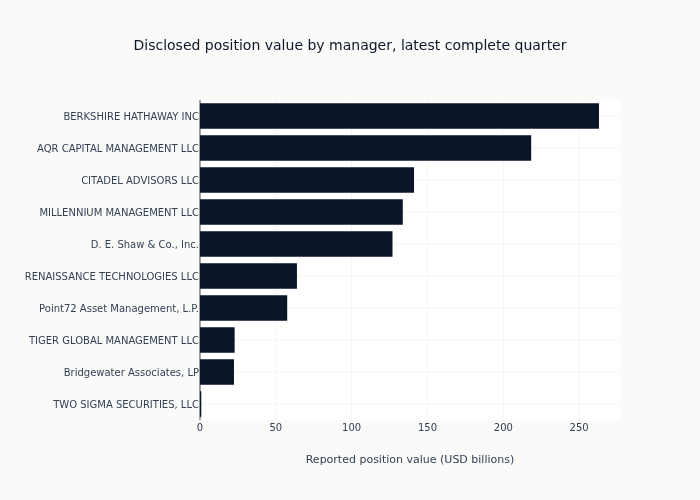

In [23]:
if len(latest_holdings) > 0:
    # Plot 1: Holdings distribution by institution
    inst_stats = (
        latest_holdings.group_by(["cik", "company_name"])
        .agg(
            [
                pl.col("cusip").n_unique().alias("n_holdings"),
                (pl.col("reported_value_usd").sum() / 1e9).alias("total_value_usd_bn"),
            ]
        )
        .with_columns(pl.col("company_name").alias("institution_name"))
        .sort("total_value_usd_bn")
    )

    fig1 = go.Figure(
        go.Bar(
            x=inst_stats["total_value_usd_bn"],
            y=inst_stats["institution_name"],
            orientation="h",
            marker_color=COLORS["blue"],
            customdata=inst_stats["n_holdings"],
            hovertemplate="%{y}<br>Value: $%{x:.1f}B<br>Positions: %{customdata}<extra></extra>",
        )
    )
    fig1.update_layout(
        title="Disclosed position value by manager, latest complete quarter",
        xaxis_title="Reported position value (USD billions)",
        yaxis_title=None,
        height=500,
        showlegend=False,
        margin=dict(l=200),
    )
    show_plotly_with_alt(
        fig1,
        "A horizontal bar chart of ten managers' disclosed long-equity value in billions of "
        "dollars, longest at the top. Berkshire Hathaway leads by a wide margin, AQR Capital "
        "follows, then Citadel, Millennium and D. E. Shaw close together at about half "
        "Berkshire's length. Renaissance, Point72, Tiger Global and Bridgewater are shorter "
        "again, and Two Sigma Securities is last with a bar barely distinguishable from zero.",
    )

Length is disclosed dollars; the position count is on hover. A manager short
and wide holds many small positions, one long and narrow holds few large
ones, and neither is visible from the bar alone.

In [24]:
if len(latest_holdings) > 0:
    # Plot 2: Top holdings across all institutions
    top_stocks = (
        latest_holdings.group_by("cusip")
        .agg(
            [
                pl.col("issuer").first().alias("issuer"),
                pl.col("cik").n_unique().alias("n_institutions"),
                (pl.col("reported_value_usd").sum() / 1e9).alias("total_value_usd_bn"),
            ]
        )
        .sort(
            ["n_institutions", "total_value_usd_bn", "cusip"],
            descending=[True, True, False],
        )
        .head(20)
        .with_columns(
            (pl.col("issuer") + pl.lit(" [") + pl.col("cusip").str.slice(-4) + pl.lit("]")).alias(
                "display_label"
            )
        )
    )

Use a horizontal bar chart for the deterministic breadth-first selection.
The CUSIP suffix makes every categorical label unique.

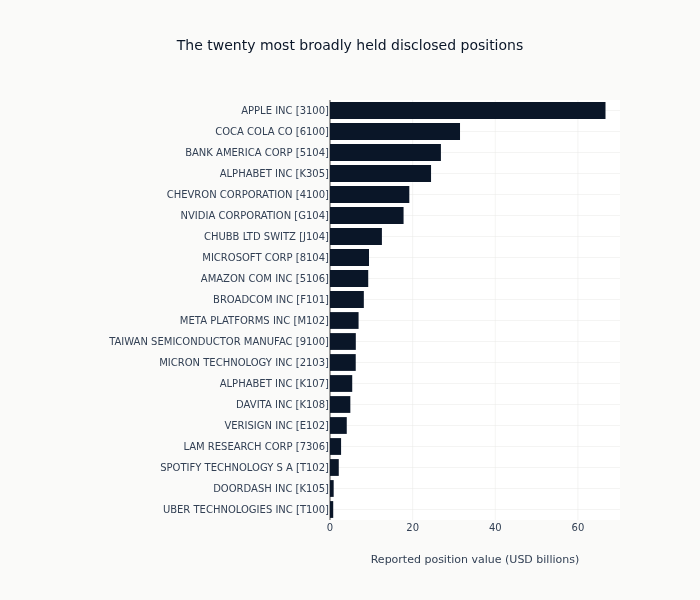

In [25]:
if len(latest_holdings) > 0:
    top_stocks_pd = top_stocks.sort("total_value_usd_bn", descending=False).to_pandas()
    fig2 = go.Figure(
        go.Bar(
            x=top_stocks_pd["total_value_usd_bn"],
            y=top_stocks_pd["display_label"],
            orientation="h",
            marker_color=COLORS["blue"],
            customdata=top_stocks_pd["n_institutions"],
            hovertemplate="%{y}<br>Value: $%{x:.1f}B<br>Managers: %{customdata}<extra></extra>",
        )
    )
    fig2.update_layout(
        title="The twenty most broadly held disclosed positions",
        xaxis_title="Reported position value (USD billions)",
        yaxis_title=None,
        height=600,
        margin=dict(l=330),
    )
    show_plotly_with_alt(
        fig2,
        "A horizontal bar chart of twenty holdings, each labelled with the issuer name and the "
        "last four characters of its CUSIP, longest at the top. Apple is roughly twice the "
        "length of the second bar and the lengths fall away steeply after the first five, with "
        "the last several close to zero. Two rows carry the same issuer name with different "
        "CUSIP suffixes, which are its two share classes.",
    )

Selection here is by breadth first and value second, so the ordering by bar
length is not the ordering that chose the twenty. Breadth is a description of
who discloses a name, not evidence about what it will do.

Selection is by the SIZE of the move rather than by its sign. Sorting on the
signed change and taking the head puts only increases on a chart whose zero
lines invite reading four quadrants.

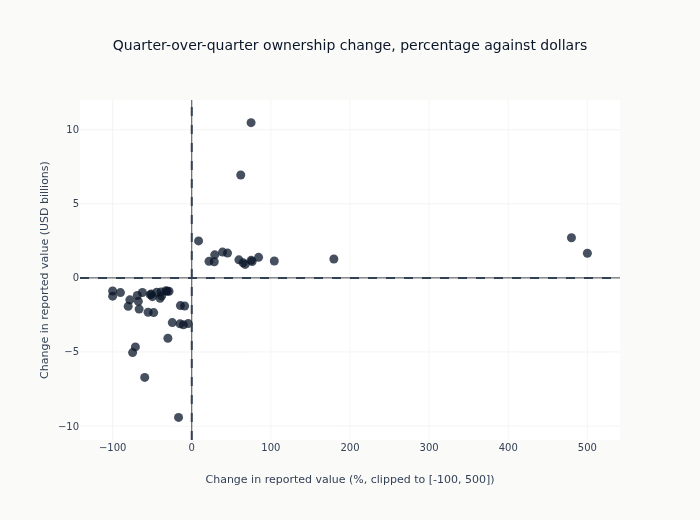

In [26]:
if qoq is not None and len(qoq) > 0:
    momentum_plot = (
        qoq.filter(pl.col("n_institutions") >= 2)
        .filter(pl.col("pct_change").is_not_null())
        .sort(pl.col("value_change_usd").abs(), descending=True)
    )

    if len(momentum_plot) > 0:
        mom_pd = momentum_plot.head(50).to_pandas()
        mom_pd["pct_change_pct"] = (100 * mom_pd["pct_change"]).clip(lower=-100, upper=500)
        mom_pd["value_change_usd_bn"] = mom_pd["value_change_usd"] / 1e9
        fig3 = go.Figure(
            go.Scatter(
                x=mom_pd["pct_change_pct"],
                y=mom_pd["value_change_usd_bn"],
                mode="markers",
                marker=dict(color=COLORS["blue"], size=9, opacity=0.75),
                text=mom_pd["issuer_name"],
                hovertemplate=(
                    "%{text}<br>Change: %{x:.1f}%<br>Value change: $%{y:.2f}B<extra></extra>"
                ),
            )
        )
        fig3.update_layout(
            title="Quarter-over-quarter ownership change, percentage against dollars",
            xaxis_title="Change in reported value (%, clipped to [-100, 500])",
            yaxis_title="Change in reported value (USD billions)",
            height=520,
            showlegend=False,
        )
        fig3.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])
        fig3.add_vline(x=0, line_dash="dash", line_color=COLORS["neutral"])
        show_plotly_with_alt(
            fig3,
            "A scatter of fifty holdings, percentage change in reported value on the horizontal "
            "axis against dollar change in billions on the vertical, with dashed reference lines at "
            "zero on both. The points form a low band close to the horizontal zero line and spread "
            "the full width of the percentage axis; two sit far above the band at a modest "
            "percentage change, and two sit at the far right of the percentage axis with a small "
            "dollar change. The two axes rank the same holdings differently.",
        )

The fifty largest moves by absolute dollar change, in both directions. The
horizontal axis is clipped at the bounds its own label names, so a point on
either edge is at or beyond the cap rather than exactly at it.

Both axes are here because they disagree. A large percentage change on a
small base is a small dollar change, and the points furthest to the right are
not the ones furthest up.

## Part 8: Feature Engineering for ML Models

Create point-in-time features that can be joined to price data for validation.

In [27]:
if len(latest_holdings) > 0:
    # Stock-level features for ML
    stock_features = (
        latest_holdings.group_by("cusip")
        .agg(
            [
                pl.col("issuer").first().alias("issuer_name"),
                # Ownership breadth
                pl.col("cik").n_unique().alias("n_inst_holders"),
                # Value concentration
                pl.col("reported_value_usd").sum().alias("total_inst_value_usd"),
                pl.col("reported_value_usd").mean().alias("avg_position_size_usd"),
                pl.col("reported_value_usd").std().fill_null(0).alias("position_size_std_usd"),
                pl.col("timestamp").max().alias("timestamp"),
                # Ownership concentration (HHI)
                (pl.col("reported_value_usd") / pl.col("reported_value_usd").sum())
                .pow(2)
                .sum()
                .alias("ownership_hhi"),
            ]
        )
        .with_columns(
            [
                # Breadth over the managers in the graph, the producer's denominator.
                (pl.col("n_inst_holders") / latest_holdings["cik"].n_unique()).alias(
                    "inst_coverage_pct"
                ),
                (
                    pl.col("position_size_std_usd")
                    / pl.col("avg_position_size_usd").clip(lower_bound=1)
                ).alias("position_cv"),
            ]
        )
        .sort("cusip")
    )

    print("=== Stock-Level Features for ML ===")
    print(f"Features generated for {len(stock_features)} stocks")
    print("\nFeature summary:")
    print(stock_features.describe())

=== Stock-Level Features for ML ===
Features generated for 7998 stocks

Feature summary:
shape: (9, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ cusip     ┆ issuer_na ┆ n_inst_ho ┆ … ┆ timestamp ┆ ownership ┆ inst_cove ┆ position │
│ ---       ┆ ---       ┆ me        ┆ lders     ┆   ┆ ---       ┆ _hhi      ┆ rage_pct  ┆ _cv      │
│ str       ┆ str       ┆ ---       ┆ ---       ┆   ┆ str       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆ str       ┆ f64       ┆   ┆           ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 7998      ┆ 7998      ┆ 7998.0    ┆ … ┆ 7998      ┆ 7998.0    ┆ 7998.0    ┆ 7998.0   │
│ null_coun ┆ 0         ┆ 0         ┆ 0.0       ┆ … ┆ 0         ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           

Every feature is as of a quarter end and becomes usable at the availability
timestamp, not at the quarter end. How long any of them stays informative is
not established here.

In [28]:
if len(latest_holdings) > 0:
    # Add momentum features if available
    if qoq is not None and len(qoq) > 0:
        momentum_features = qoq.select(
            [
                "cusip",
                pl.col("value_change_usd").alias("inst_value_change_usd"),
                pl.col("pct_change").alias("inst_pct_change"),
            ]
        )
        stock_features = (
            stock_features.join(momentum_features, on="cusip", how="left")
            .with_columns(pl.col("inst_value_change_usd").fill_null(0))
            .sort("cusip")
        )
        print("Added momentum features")
    else:
        # One complete quarter: the producer still emits both columns, so match it.
        stock_features = stock_features.with_columns(
            pl.lit(0.0, dtype=pl.Float64).alias("inst_value_change_usd"),
            pl.lit(None, dtype=pl.Float64).alias("inst_pct_change"),
        ).sort("cusip")
        print("Single complete quarter: momentum columns emitted as 0.0 / null")

    display(stock_features.head(10))

Added momentum features


cusip,issuer_name,n_inst_holders,total_inst_value_usd,avg_position_size_usd,position_size_std_usd,timestamp,ownership_hhi,inst_coverage_pct,position_cv,inst_value_change_usd,inst_pct_change
str,str,u32,f64,f64,f64,date,f64,f64,f64,f64,f64
"""00032Q104""","""WHITEHAWK THERAPEUTICS INC""",4,2.9607e6,740175.0,644579.021549,2026-05-15,0.392195,0.4,0.870847,1.654694e6,1.266988
"""000360206""","""AAON INC""",4,3.4879623e7,8.7199e6,1.4905e7,2026-05-15,0.797826,0.4,1.709309,-6.73903e6,-0.161923
"""000361105""","""AAR CORP""",5,1.1035429e7,2207085.8,1.8525e6,2026-05-15,0.312714,0.5,0.839322,-7.988389e6,-0.419915
"""00039J301""","""AB ACTIVE ETFS INC""",1,551959.0,551959.0,0.0,2026-05-15,1.0,0.1,0.0,129364.0,0.306118
"""00039J509""","""AB ACTIVE ETFS INC""",1,241763.0,241763.0,0.0,2026-05-15,1.0,0.1,0.0,9242.0,0.039747
"""00039J707""","""AB ACTIVE ETFS INC""",1,664955.0,664955.0,0.0,2026-05-15,1.0,0.1,0.0,664955.0,null
"""00039J764""","""AB ACTIVE ETFS INC""",1,251945.0,251945.0,0.0,2026-05-15,1.0,0.1,0.0,251945.0,null
"""00039J772""","""AB ACTIVE ETFS INC""",1,253526.0,253526.0,0.0,2026-05-15,1.0,0.1,0.0,253526.0,null
"""00039J822""","""AB ACTIVE ETFS INC""",2,1.150455e6,575227.5,149498.636999,2026-05-15,0.516886,0.2,0.259895,425445.0,0.586813


### Canonical artifact parity

Confirm that the downloader's latest-quarter edge and feature artifacts are
the same objects constructed above, rather than stale snapshots.

In [29]:
if len(latest_holdings) > 0:
    expected_edges = latest_holdings.select(
        pl.col("cik").alias("institution_id"),
        pl.col("cusip").alias("stock_id"),
        pl.col("company_name").alias("institution_name"),
        pl.col("issuer").alias("stock_name"),
        pl.col("reported_value_usd").alias("weight_value"),
        pl.col("shares").alias("weight_shares"),
        pl.col("report_period").alias("report_date"),
        "timestamp",
    )
    canonical_edges = load_13f_edges()
    canonical_features = load_13f_stock_features()
    assert_frame_equal(
        expected_edges.sort(["institution_id", "stock_id"]),
        canonical_edges.sort(["institution_id", "stock_id"]),
        check_row_order=True,
    )
    assert_frame_equal(
        stock_features.sort("cusip"),
        canonical_features.sort("cusip"),
        check_row_order=True,
        rel_tol=1e-6,
    )
    print("Canonical edge and stock-feature artifact parity: PASS")

Canonical edge and stock-feature artifact parity: PASS


The assertion above is the point of the section: this notebook reconstructs
what the downloader wrote and checks the two frames are equal, so a reader
can see how the shipped artifact was built rather than taking it on trust. A
drift between them fails here instead of surfacing as a puzzling number in
Chapter 23.

## Part 9: Artifacts on Disk

The canonical downloader writes all graph artifacts (holdings, edge list,
stock features, co-ownership matrix, stock list) to
`$ML4T_DATA_PATH/equities/positioning/13f/`. Chapter 23 notebooks read
those files directly via `load_13f_edges()` and `load_13f_stock_features()`.
This notebook is a consumer of the holdings artifact, not a producer - its
derived tables (above) are for inspection and pedagogy only.

In [30]:
print("=== Canonical 13F Artifacts ===")
print("Writer:    data/equities/positioning/13f_download.py")
print("Location:  $ML4T_DATA_PATH/equities/positioning/13f/")
print("Files:     institutional_holdings.parquet")
print("           institution_stock_edges.parquet")
print("           stock_features.parquet")
print("           coownership_matrix.npy")
print("           coownership_stocks.txt")
print("Loaders:   load_institutional_holdings_13f(), load_13f_edges(),")
print("           load_13f_stock_features()")

=== Canonical 13F Artifacts ===
Writer:    data/equities/positioning/13f_download.py
Location:  $ML4T_DATA_PATH/equities/positioning/13f/
Files:     institutional_holdings.parquet
           institution_stock_edges.parquet
           stock_features.parquet
           coownership_matrix.npy
           coownership_stocks.txt
Loaders:   load_institutional_holdings_13f(), load_13f_edges(),
           load_13f_stock_features()


## Results interpretation

**Co-ownership structure.** This graph is not sparse, and the numbers to read
it by are printed in Part 2 and Part 3 rather than asserted here: the
bipartite density, the share of stock pairs sharing no holder, and the share
sitting at the top of the similarity scale. Ten large managers holding a few
thousand names each produce a densely connected graph, and the similarity
saturates because each stock is described by ten numbers. Both facts are
properties of the manager universe rather than of institutional ownership,
and widening the universe changes them.

**Institutional ownership change.** Quarter-over-quarter changes describe how
aggregate reported holdings moved between the two most recent quarters every
included manager filed for. The availability timestamp records when that
snapshot became observable. No persistence or forward-return claim is made or
tested.

**Crowding.** The score is breadth divided by ownership concentration, and
Part 5 says what that makes it: holder count sets a ceiling of its square,
and concentration pulls a name below that ceiling by enough that fewer,
evenly weighted holders can outrank more uneven ones. It describes disclosed
structure. It does not observe liquidation or price impact, and it is not on
a scale that means anything outside this manager universe.

## Summary: What We Can Do With 13F Data

### Implemented Features

| Feature | Description | Use Case |
|---------|-------------|----------|
| `n_inst_holders` | Number of institutions holding stock | Crowding risk |
| `total_inst_value_usd` | Total reported position value (USD) | Ownership scale |
| `ownership_hhi` | Concentration of ownership | Crowding risk |
| `inst_value_change_usd` | Quarter-over-quarter value change | Ownership change |
| `inst_pct_change` | Fractional change in reported value | Ownership change |
| Co-ownership matrix | Stock-stock similarity | Clustering, GNN |

In [31]:
print("\n=== Analysis Summary ===")
if len(positions_df) > 0:
    print(f"Institutions: {positions_df['cik'].n_unique()}")
    print(f"Unique stocks: {positions_df['cusip'].n_unique()}")
    print(f"Aggregated positions: {len(positions_df):,}")
    try:
        print(f"Stock features (derived): {len(stock_features)}")
    except NameError:
        print("Stock features (derived): 0")


=== Analysis Summary ===
Institutions: 10
Unique stocks: 10273
Aggregated positions: 95,845
Stock features (derived): 7998


## Key takeaways

1. SEC 13F filings provide a structured, machine-readable view of institutional
   equity ownership. The canonical downloader at
   `data/equities/positioning/13f_download.py` walks EDGAR and writes a
   normalized holdings artifact consumed here via `load_institutional_holdings_13f()`.
2. **A cosine's effective dimension is set by its weights, not by its
   non-zeros.** Each stock here is described by ten numbers, one per manager,
   and over a third are held by exactly one - two such stocks score exactly 1
   whenever that manager is the same, which is why millions of pairs sit at
   the top of the scale and "the highest-similarity pair" is an arbitrary pick
   from a tie. Requiring more holders thins that out, but the top pair is
   still at 1 with five holders each, because one manager carries the great
   majority of both positions. Part 3 measures both, and the check to carry
   away is to report a concentration next to any similarity computed over a
   short vector.
3. **The crowding score mixes two things and neither dominates.** Holder
   count over ownership HHI reaches its maximum, the square of the holder
   count, only when those holders are equally weighted; concentration pulls a
   name below that, far enough that three equal holders can outrank four with
   one dominant. It is not a breadth ranking with a tie-break, and its
   magnitude means nothing outside this manager universe. Quarter-over-quarter
   change and concentration are descriptive candidates whose predictive value
   requires a point-in-time return study.
4. **The identity is the CIK and the name comes from the filing.** A
   hand-written display name that disagrees with the filer renames a manager
   in every table downstream, and this notebook carried one: the CIK labelled
   "Two Sigma Investments" files as Two Sigma Securities, a different book.
5. The 45-day filing deadline limits real-time use; `timestamp` records when
   the complete included-manager snapshot becomes available.

**Chapter Connections**:
- **Chapter 23 (Knowledge Graphs)**: Use the bipartite graph for GNN message passing
- **Chapter 11 (ML Pipeline)**: Join features to price data for cross-sectional models
- **Chapter 12 (Gradient Boosting)**: Use crowding and ownership change as tree model features
- **Chapter 24 (Autonomous Agents)**: Natural language queries about institutional holdings

**Limitations**:
- Only long equity positions (no shorts, no derivatives)
- >$100M AUM threshold misses smaller funds
- Confidential treatment exemptions hide some positions

**Next**: Chapter 23 converts these ownership links into structured graph
representations, while Chapter 24 uses the same entities in agentic workflows.